Loading Frames...
Number of frames: 7776
Loading Gaze Labels...
Frame-gaze alignment: median gap 2678 µs, max 1457807 µs, 95th pct 6912 µs
Loading Events...
Number of events: 15943570


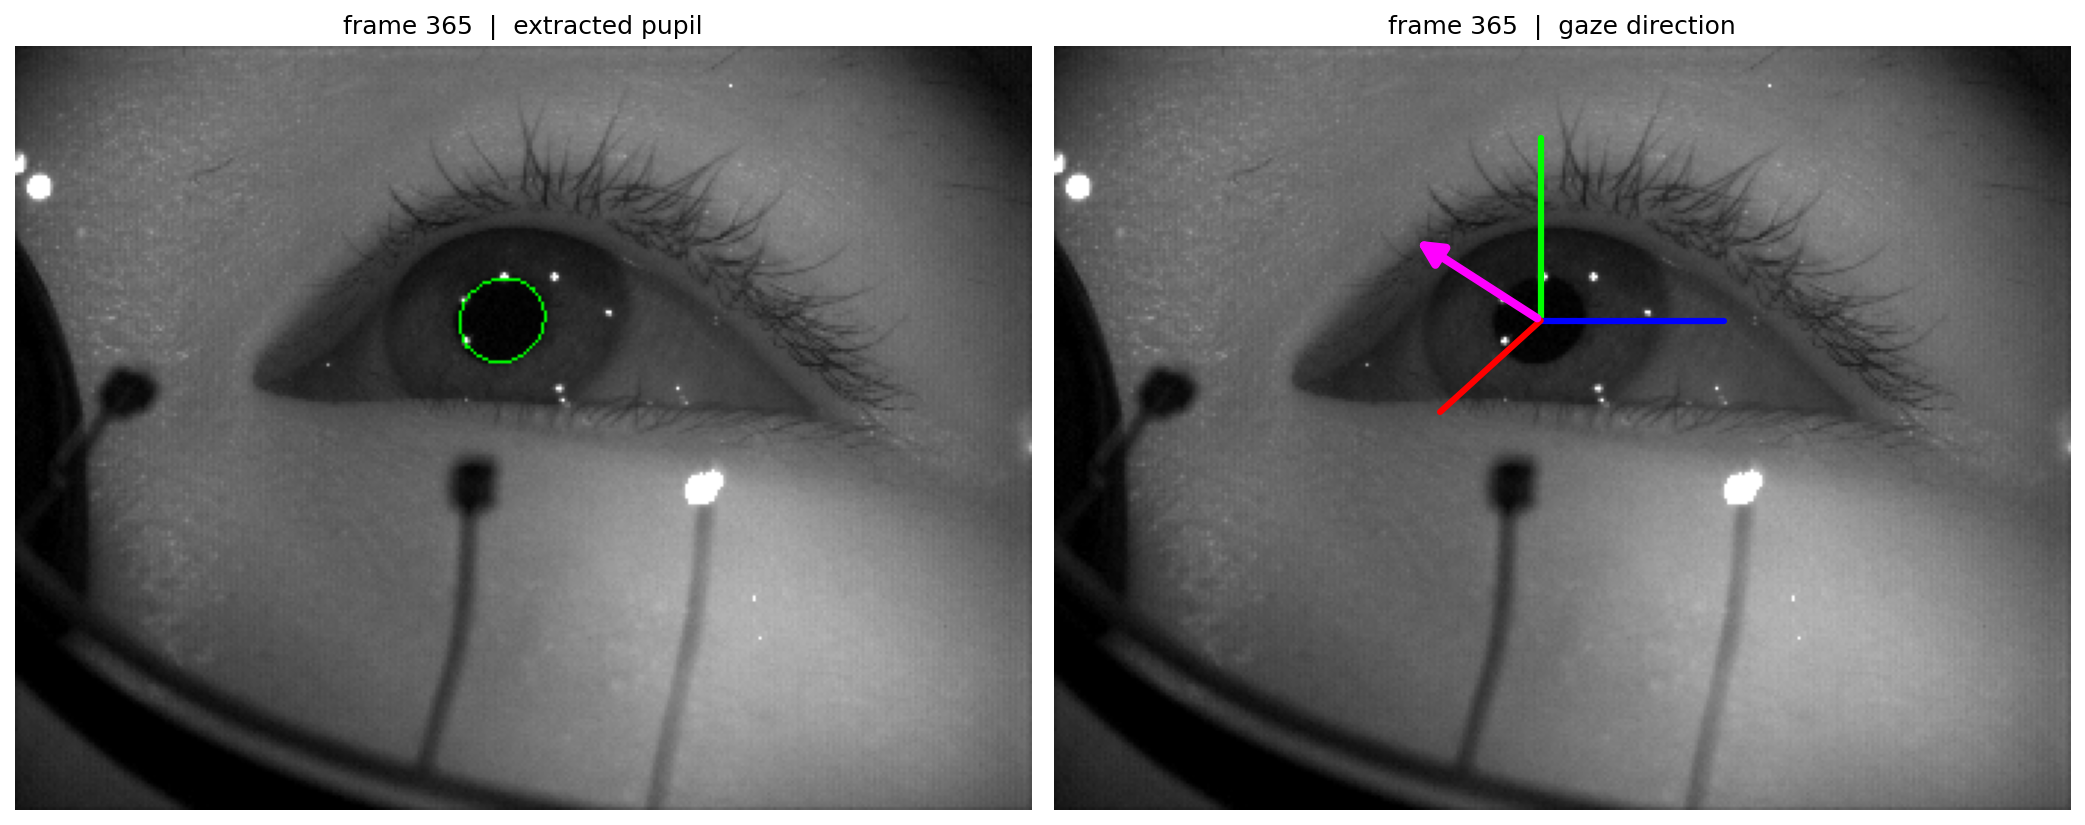

In [1]:
import os, sys

# Make the project's `src/` importable and resolve data paths relative to the repo root.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))

import cv2
import numpy as np
import matplotlib.pyplot as plt

from data.loaders import EvEyeDataset
from config import DATASET_PATHS, get_frame_detection_config
from processing.frame_detection import _run_detection

# --- Settings: image 365 of subject 22 (ev_eye, left eye, saccadic) ---
SUBJECT = 22
EYE = 'left'
MOTION = 'saccadic'
FRAME_IDX = 365  # chronological index, same number shown by pe_browse

# Load frames (frame_list is stored newest-first; pe_browse shows frame_idx = n-1-list_idx).
ds = EvEyeDataset(DATASET_PATHS['ev_eye'], SUBJECT, motion=MOTION, mode='np')
ds.collect_data(eye=EYE)
n = len(ds.frame_list)
frame = ds.frame_list[n - 1 - FRAME_IDX]

config = get_frame_detection_config(SUBJECT, EYE, 'ev_eye')

# Run the same detection pipeline pe_browse uses; we only need the image + fitted ellipse.
img, _binary, _opened, _contour_img, _selected_points, ellipse = _run_detection(frame, config)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# --- Left: extracted pupil overlaid on the image (panel (f) of pe_browse) ---
img_with_ellipse = img_rgb.copy()
if ellipse is not None:
    cv2.ellipse(img_with_ellipse, ellipse, (0, 255, 0), 1)
ax_l.imshow(img_with_ellipse)
ax_l.set_title(f'frame {FRAME_IDX}  |  extracted pupil')
ax_l.axis('off')

# --- Right: same image with 3D-style axes + gaze direction arrow (purple, top-left) ---
ax_r.imshow(img_rgb)
if ellipse is not None:
    cx, cy = ellipse[0]
else:
    cy, cx = (np.array(img.shape[:2]) / 2)

L = 0.18 * img.shape[1]  # axis length ~ fraction of image width
# (dx, dy) in image pixels (y points down). Directions match the example figure.
axes_dirs = [
    ((0.0, -L),            'lime',  3),   # green: up
    ((L, 0.0),             'blue',  3),   # blue:  right
    ((-0.55 * L, 0.5 * L), 'red',   3),   # red:   down-left
]
# x/y/z axes drawn as plain lines (no arrowheads).
for (dx, dy), color, lw in axes_dirs:
    ax_r.plot([cx, cx + dx], [cy, cy + dy], color=color, lw=lw,
              solid_capstyle='round')

# Gaze direction: purple/magenta arrow pointing top-left, as in the example.
gdx, gdy = (-0.7 * L, -0.45 * L)
ax_r.annotate('', xy=(cx + gdx, cy + gdy), xytext=(cx, cy),
              arrowprops=dict(arrowstyle='-|>', color='magenta', lw=4,
                              mutation_scale=24))

ax_r.set_title(f'frame {FRAME_IDX}  |  gaze direction')
ax_r.axis('off')

plt.tight_layout()
plt.show()

In [2]:
import os, sys
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))

import cv2
import numpy as np

from data.loaders import EvEyeDataset
from config import DATASET_PATHS, get_frame_detection_config
from processing.frame_detection import _run_detection

# --- Settings: frame 4000 of subject 7 (ev_eye, left eye, saccadic) ---
SUBJECT   = 7
EYE       = 'left'
MOTION    = 'saccadic'
DATASET   = 'ev_eye'
FRAME_IDX = 4000  # chronological index, same number shown by pe_browse
OUT_DIR   = os.path.join(REPO_ROOT, 'notebooks', f'subject{SUBJECT}_{FRAME_IDX}')
os.makedirs(OUT_DIR, exist_ok=True)

# Load frames (frame_list is stored newest-first; pe_browse shows frame_idx = n-1-list_idx).
ds = EvEyeDataset(DATASET_PATHS[DATASET], SUBJECT, motion=MOTION, mode='np')
ds.collect_data(eye=EYE)
n = len(ds.frame_list)
frame = ds.frame_list[n - 1 - FRAME_IDX]

config = get_frame_detection_config(SUBJECT, EYE, DATASET)

# Same 6 stages pe_browse renders: (a) gray, (b) threshold, (c) opened,
# (d) contours, (e) selected-blob points, (f) chosen ellipse.
img, binary, opened, contour_img, selected_points, ellipse = _run_detection(frame, config)

# Panel (e): instead of highlighting only the chosen blob, fit an ellipse to
# *every* blob (contour with >= 5 points) found in the opened image and draw
# them all, so the figure shows all candidate ellipses before selection.
all_ellipses_img = img.copy()
contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
for cnt in contours:
    if len(cnt) < 5:
        continue
    cv2.ellipse(all_ellipses_img, cv2.fitEllipse(cnt), (0, 255, 0), 1)

# Panel (f): chosen ellipse in green (as in pe_browse).
selected_ellipse_img = img.copy()
if ellipse is not None:
    cv2.ellipse(selected_ellipse_img, ellipse, (0, 255, 0), 1)

# Save all 6 panels. cv2.imwrite handles single-channel (b,c,d) and BGR (a,e,f).
panels = {
    'a_grayscale.png':        img,
    'b_threshold.png':        binary,
    'c_opened.png':           opened,
    'd_contours.png':         contour_img,
    'e_all_ellipses.png':     all_ellipses_img,
    'f_selected_ellipse.png': selected_ellipse_img,
}
for fname, im in panels.items():
    cv2.imwrite(os.path.join(OUT_DIR, fname), im)

print(f"Saved {len(panels)} panels -> {OUT_DIR}")


Loading Frames...
Number of frames: 7690
Loading Gaze Labels...
Frame-gaze alignment: median gap 2742 µs, max 1611285 µs, 95th pct 7698 µs
Loading Events...
Number of events: 13350055
Saved 6 panels -> /home/kmirinski/uni/msc/thesis/eye_tracking_thesis/notebooks/subject7_4000


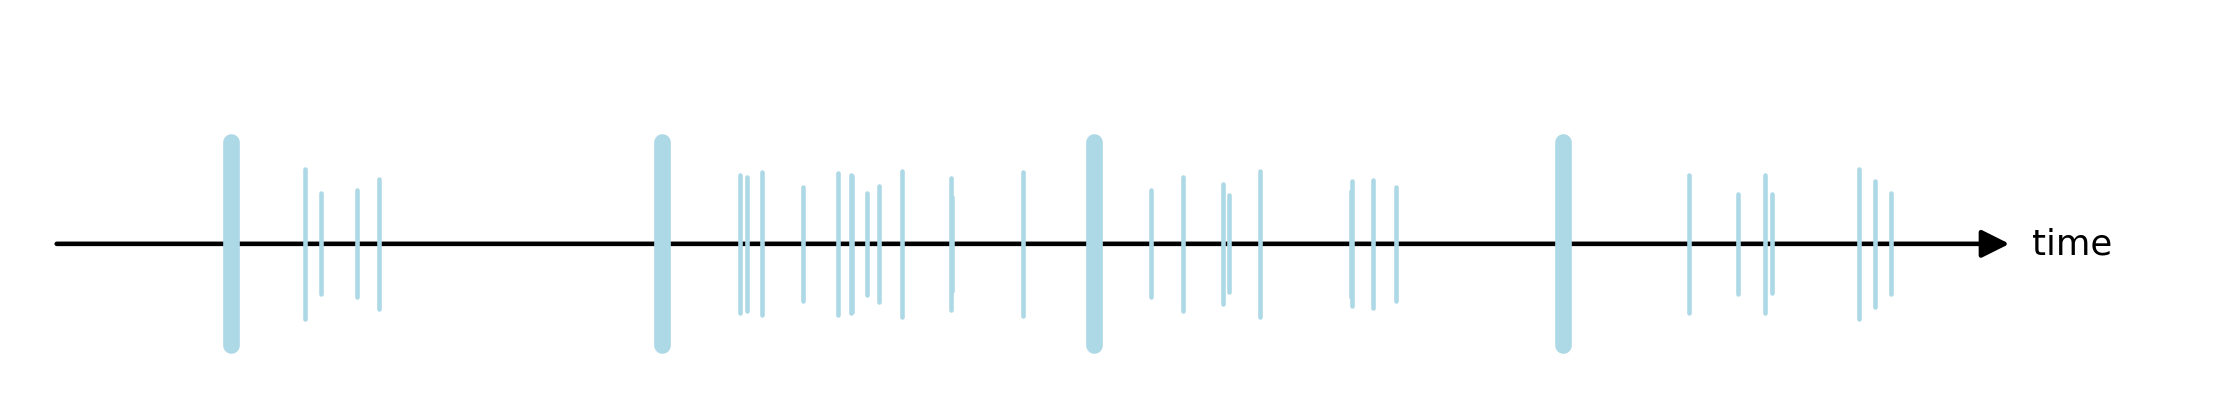

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Schematic event/frame timeline: thick bars = APS frames, thin ticks = events.
# Illustrative (not real data).
fig, ax = plt.subplots(figsize=(15, 2.8), dpi=150)
y, xmax = 0.0, 20.0

# --- main time axis with arrowhead + label (kept under the ticks) ---
ax.annotate('', xy=(xmax + 0.6, y), xytext=(-0.3, y), zorder=1,
            arrowprops=dict(arrowstyle='-|>', color='black', lw=2.2, mutation_scale=28))
ax.text(xmax + 0.8, y, 'time', fontsize=17, va='center', ha='left')

# --- frame markers (thick rounded bars) ---
frame_times = [1.6, 6.2, 10.8, 15.8]
for t in frame_times:
    ax.plot([t, t], [-0.42, 0.42], color='lightblue', lw=8, solid_capstyle='round', zorder=3)

# --- event ticks (thin, varying heights), denser in clusters; drawn over the axis ---
rng = np.random.default_rng(3)
event_times = np.concatenate([
    rng.uniform(2.3, 3.4, 4),
    rng.uniform(6.7, 10.2, 13),   # dense cluster
    rng.uniform(11.4, 12.6, 5),
    rng.uniform(13.3, 14.1, 4),
    rng.uniform(17.1, 18.3, 4),
    rng.uniform(18.9, 19.5, 3),
])
for t in event_times:
    h = rng.uniform(0.18, 0.32)
    ax.plot([t, t], [-h, h], color='lightblue', lw=2.2, solid_capstyle='round', zorder=2)

ax.set_ylim(-0.6, 0.95)
ax.set_xlim(-0.7, xmax + 2.8)
ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
import os, sys
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

from data.loaders import EyeDataset
from config import DATASET_PATHS

ds = EyeDataset(DATASET_PATHS['ebveye'], 22, mode='np')
ds.collect_data(eye=0, motion='saccadic')

N_SETS   = 150
N_EVENTS = 2000
events_all = ds.event_list[:N_SETS * N_EVENTS].reshape(N_SETS, N_EVENTS, 4)

# Average time span across all 20 sets
diffs_us = events_all[:, -1, 3] - events_all[:, 0, 3]
avg_diff_us = diffs_us.mean()
print(f"Per-set time span (µs): {diffs_us}")
print(f"Average time span     : {avg_diff_us:.1f} µs  ({avg_diff_us / 1e3:.3f} ms)")

# Build GIF
fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
ax.set_xlim(0, 346)
ax.set_ylim(260, 0)
ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
scat_pos = ax.scatter([], [], s=2, c='green', alpha=0.8, linewidths=0, label='positive')
scat_neg = ax.scatter([], [], s=2, c='red',   alpha=0.8, linewidths=0, label='negative')
ax.legend(markerscale=4, loc='upper left')
title = ax.set_title('')

def update(i):
    evs = events_all[i]
    pos = evs[evs[:, 0] == 1]
    neg = evs[evs[:, 0] == 0]
    scat_pos.set_offsets(pos[:, [2, 1]] if len(pos) else np.empty((0, 2)))
    scat_neg.set_offsets(neg[:, [2, 1]] if len(neg) else np.empty((0, 2)))
    # title.set_text(f'Set {i + 1}/{N_SETS}  —  span: {diffs_us[i]:.0f} µs  ({diffs_us[i]/1e3:.2f} ms)')
    return scat_pos, scat_neg, title

ani = animation.FuncAnimation(fig, update, frames=N_SETS, interval=300, blit=True)

out_path = os.path.join(REPO_ROOT, 'notebooks', 'events.gif')
ani.save(out_path, writer='pillow', fps=11)
plt.close(fig)
print(f"Saved: {out_path}")


Loading Frames...
Number of frames: 4516
Loading Events...
Number of events: 18660125
Per-set time span (µs): [380630   9623   6888   6931   9627  20688  54010 167537 435093 610489
   8461   4732   5851   9957 188954   4996   5057   5517  10172 229571
 211854 373016 107161 267419   9797   9224 347792   9936   4588   3021
   2155   1883   1778   1780   1736   1727   1714   1726   1663   1490
   1449   1440   1390   1285   1185   1205   1111   1049   1086    991
   1006   1025    977   1056   1009   1076   1077   1134   1143   1056
   1199   1278   1289   1365   1444   1387   1372   1302   1526   1683
   1648   2935   7406   4492   3155   2785   2711   2613   2604   2904
   2802   2829   2839   3068   3258   3342   3517   3633   3499   3566
   3493   3613   4087   4375   4726   4921   5063   5384   5537   5412
   6000   7300   8222   8711   7795  13147  23658  13673   3420   2851
   2708   2660   2856   2990   3117   3425   5156  26179  37279  56278
  34947 239250 654635 299796   3048   

In [4]:
import os, sys
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))

import cv2
import numpy as np
from PIL import Image
from data.loaders import EvEyeDataset
from config import DATASET_PATHS, get_frame_detection_config
from processing.frame_detection import _run_detection

SUBJECT  = 22
EYE      = 'left'
MOTION   = 'saccadic'
START    = 384
END      = 421   # inclusive
FPS      = 8
OUT_PATH = os.path.join(REPO_ROOT, 'notebooks', 'pupil_384_421.gif')

ds = EvEyeDataset(DATASET_PATHS['ev_eye'], SUBJECT, motion=MOTION, mode='np')
ds.collect_data(eye=EYE)
n = len(ds.frame_list)
config = get_frame_detection_config(SUBJECT, EYE, 'ev_eye')

frames_pil = []
for frame_idx in range(START, END + 1):
    list_idx = n - 1 - frame_idx
    frame = ds.frame_list[list_idx]
    img, _, _, _, _, ellipse = _run_detection(frame, config)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if ellipse is not None:
        cv2.ellipse(img_rgb, ellipse, (0, 255, 0), 1)
        cx, cy = int(ellipse[0][0]), int(ellipse[0][1])
        cv2.drawMarker(img_rgb, (cx, cy), (255, 0, 0), cv2.MARKER_CROSS, 12, 1)

    # burn frame index into corner
    cv2.putText(img_rgb, f'frame {frame_idx}', (4, 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (220, 220, 220), 1)

    frames_pil.append(Image.fromarray(img_rgb))

frames_pil[0].save(
    OUT_PATH,
    save_all=True,
    append_images=frames_pil[1:],
    loop=0,
    duration=int(1000 / FPS),
)
print(f"Saved {len(frames_pil)} frames → {OUT_PATH}")


Loading Frames...
Number of frames: 7776
Loading Gaze Labels...
Frame-gaze alignment: median gap 2678 µs, max 1457807 µs, 95th pct 6912 µs
Loading Events...
Number of events: 15943570
Saved 38 frames → /home/kmirinski/uni/msc/thesis/eye_tracking_thesis/notebooks/pupil_384_421.gif


In [3]:
import os, sys
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(REPO_ROOT, 'src'))

import cv2
import numpy as np
from PIL import Image
from data.loaders import EyeDataset, get_path_info
from config import DATASET_PATHS, get_frame_detection_config
from processing.frame_detection import _run_detection

SUBJECT  = 22
EYE      = 'left'
MOTION   = 'saccadic'
START    = 384
END      = 421
FPS      = 8
OUT_PATH = os.path.join(REPO_ROOT, 'notebooks', 'pupil_384_421.gif')

ds = EyeDataset(DATASET_PATHS['ebveye'], SUBJECT, mode='np')
ds.collect_data(eye=0, motion=MOTION)
config = get_frame_detection_config(SUBJECT, EYE, 'ebveye')

# Filter frames by file index (the leading number in the filename)
selected = [f for f in ds.frame_list if START <= get_path_info(f.img)['index'] <= END]
selected.sort(key=lambda f: get_path_info(f.img)['index'])

frames_pil = []
for frame in selected:
    info = get_path_info(frame.img)
    img, _, _, _, _, ellipse = _run_detection(frame, config)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if ellipse is not None:
        cv2.ellipse(img_rgb, ellipse, (0, 255, 0), 1)
        cx, cy = int(ellipse[0][0]), int(ellipse[0][1])
        cv2.drawMarker(img_rgb, (cx, cy), (255, 0, 0), cv2.MARKER_CROSS, 12, 1)

    cv2.putText(img_rgb, f'idx {info["index"]}', (4, 14),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (220, 220, 220), 1)
    cv2.putText(img_rgb, f'label ({frame.row}, {frame.col})', (4, 28),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (220, 220, 100), 1)

    frames_pil.append(Image.fromarray(img_rgb))

frames_pil[0].save(
    OUT_PATH,
    save_all=True,
    append_images=frames_pil[1:],
    loop=0,
    duration=int(1000 / FPS),
)
print(f"Saved {len(frames_pil)} frames → {OUT_PATH}")

Loading Frames...
Number of frames: 4516
Loading Events...
Number of events: 18660125
Saved 38 frames → /home/kmirinski/uni/msc/thesis/eye_tracking_thesis/notebooks/pupil_384_421.gif
